# Einstein's Brownian Motion (1905): From Random Walk to Avogadro's Number

In this notebook we follow Albert Einstein’s line of thought in his 1905 paper
on Brownian motion. The goal is to see how:

- a simple **random walk** model
- leads to the **diffusion equation**
- which, combined with **thermodynamics** and **hydrodynamics**,
- gives a way to **measure Avogadro's number** from microscopic jitter.

We mix **history**, **theory**, and **simulation**, so that the story can be read
as both a piece of physics and a reconstruction of a great scientific discovery.

## History: Einstein, Brown, and the reality of atoms

In 1827, the botanist Robert Brown observed that tiny pollen grains suspended in
water "jiggle" endlessly under the microscope. This **Brownian motion** could
not be explained by simple currents or vibrations: even when everything looked
perfectly still, the particles refused to rest.

By the end of the 19th century, many physicists *used* atoms in their theories
(kinetic theory, thermodynamics), but some remained skeptical about whether
atoms were "real" or just convenient fictions. Brownian motion provided a
crucial test ground:

> If the jittering motion is truly caused by invisible **molecules** bombarding
> the suspended particle, then its statistics should be calculable from
> microscopic theory.

In 1905, while working at the patent office in Bern, **Albert Einstein** wrote
his famous paper _"On the motion of small particles suspended in stationary
liquids required by the molecular-kinetic theory of heat."_ In it, he:

1. Modeled the motion of a small particle as a **random walk**.
2. Derived the **diffusion equation** for the probability distribution.
3. Related the **diffusion constant** \(D\) to:
   - the **temperature** \(T\),
   - the **viscosity** \(\eta\) of the liquid,
   - the **radius** \(a\) of the particle,
   - and **Avogadro's number** \(N\).

This made Brownian motion not just a curiosity, but direct evidence that atoms
are real.

## From random walk to diffusion

Einstein's first conceptual step is to idealise the motion of a suspended
particle along one axis (say, the \(x\)-axis) as a **random walk**.

We imagine time divided into small intervals of length \(\tau\). At each step,
the particle receives a "kick" from the surrounding molecules and its position
changes by a random displacement \(\Delta x\):

- The average displacement per step is zero:
  $$
  \langle \Delta x \rangle = 0
  $$
  (no systematic drift).

- The mean-square displacement per step is some finite value:
  $$
  \langle (\Delta x)^2 \rangle = \ell^2
  $$

After \(n\) steps, at time \(t = n \tau\), the position is

$$
x(t) = \Delta x_1 + \Delta x_2 + \cdots + \Delta x_n.
$$

Assuming the steps are **independent and identically distributed**, the
mean-square displacement becomes:
$$
\langle x^2(t) \rangle
= \left\langle \left( \sum_{i=1}^n \Delta x_i \right)^2 \right\rangle
= \sum_{i=1}^n \langle (\Delta x_i)^2 \rangle
= n \ell^2
= \frac{t}{\tau} \ell^2.
$$

Einstein introduces the **diffusion constant** \(D\) via:
$$
\boxed{ \langle x^2(t) \rangle = 2 D t }.
$$

Comparing both expressions,
$$
\frac{t}{\tau} \ell^2 = 2 D t \quad \Rightarrow \quad
\boxed{ D = \frac{\ell^2}{2 \tau} }.
$$

Thus the microscopic step statistics are summarised by a single parameter
\(D\).

### Probability density and the diffusion equation

Instead of following a single particle, Einstein considers the **probability
density** $p(x,t)$: the probability of finding the particle near position
$x$ at time $t$.

In the continuum limit (small $\tau$, small step size, but fixed $D$), the
random-walk model leads to the **diffusion equation**:

$$
\boxed{
\frac{\partial p(x,t)}{\partial t}
= D \frac{\partial^2 p(x,t)}{\partial x^2}
}
$$

For an initial condition where the particle starts at the origin,

$$
p(x,0) = \delta(x),
$$

the solution is a Gaussian:

$$
\boxed{
p(x,t)
= \frac{1}{\sqrt{4 \pi D t}}
  \exp\!\left( - \frac{x^2}{4 D t} \right)
}
$$

From this, the mean-square displacement is

$$
\langle x^2(t) \rangle
= \int_{-\infty}^{\infty} x^2 p(x,t)\, dx
= 2 D t.
$$

In three dimensions, where $r^2 = x^2 + y^2 + z^2$, the analogous result is:

$$
\boxed{ \langle r^2(t) \rangle = 6 D t }.
$$

In [62]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("default")
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

# For reproducibility
rng = np.random.default_rng(0)

def random_walk_1d(n_particles=10_000, n_steps=1_000, step_std=1.0):
    """
    Simulate 1D Brownian random walks with Gaussian steps.

    Args:
        n_particles: number of independent particles
        n_steps: number of time steps
        step_std: standard deviation of each step (sqrt(<(Δx)^2>))

    Returns:
        positions: array, shape (n_steps+1, n_particles)
                   positions[t, i] = position of particle i at step t
    """
    # Initial positions: all start at 0
    positions = np.zeros((n_steps + 1, n_particles))

    # Draw all steps at once: Gaussian with mean 0 and std=step_std
    steps = rng.normal(loc=0.0, scale=step_std, size=(n_steps, n_particles))

    # Cumulative sum over steps along time axis gives positions
    positions[1:] = np.cumsum(steps, axis=0)

    return positions

# Parameters
n_particles = 50000
n_steps = 2000
step_std = 1.0

positions = random_walk_1d(n_particles=n_particles,
                           n_steps=n_steps,
                           step_std=step_std)

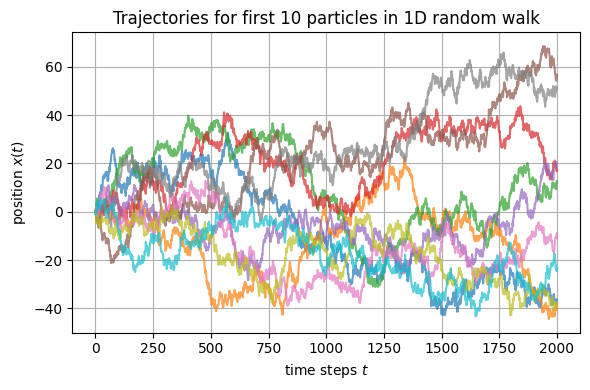

In [63]:
# Plot trajectories for first 10 particles
plt.figure(figsize=(6, 4))
plt.plot(positions[:, :10], alpha=0.7)
plt.xlabel("time steps $t$")
plt.ylabel(r"position $x(t)$")
plt.title("Trajectories for first 10 particles in 1D random walk")
plt.tight_layout()
plt.show()

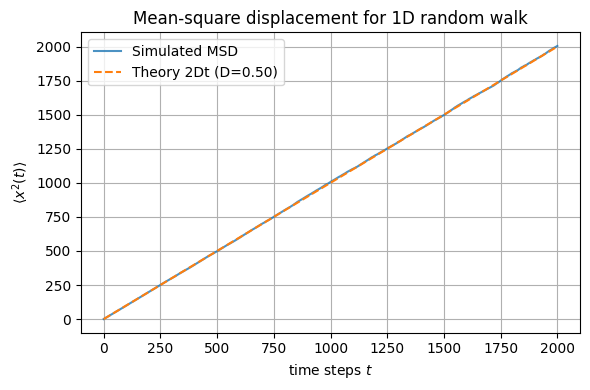

In [64]:
# Time array in "steps"
t = np.arange(n_steps + 1)

# Mean-square displacement <x^2(t)>
msd = np.mean(positions**2, axis=1)

# According to Einstein, <x^2> = 2 D t, and for our discrete walk:
# D = step_std^2 / (2 * Δt) with Δt=1
D_theory = step_std**2 / 2.0
msd_theory = 2 * D_theory * t

plt.figure(figsize=(6, 4))
plt.plot(t, msd, label="Simulated MSD", alpha=0.8)
plt.plot(t, msd_theory, "--", label=f"Theory 2Dt (D={D_theory:.2f})")
plt.xlabel("time steps $t$")
plt.ylabel(r"$\langle x^2(t) \rangle$")
plt.title("Mean-square displacement for 1D random walk")
plt.legend()
plt.tight_layout()
plt.show()

## Extension to 2D Brownian motion

In two dimensions we track a particle's position

$$
\mathbf{r}(t) = (x(t), y(t)).
$$

Assume that:

- The $x$- and $y$-components perform **independent 1D random walks**.
- Each has the same diffusion constant $D$.

Then the joint probability density is the product of two Gaussians:

$$
p(x,y,t) = \frac{1}{4 \pi D t}
\exp\!\left( -\frac{x^2 + y^2}{4 D t} \right)
= \frac{1}{4 \pi D t}
\exp\!\left( -\frac{r^2}{4 D t} \right),
$$

where $r^2 = x^2 + y^2$.

The moments of the motion are:

$$
\langle x^2(t) \rangle = 2 D t, \qquad
\langle y^2(t) \rangle = 2 D t,
$$

and therefore

$$
\langle r^2(t) \rangle
= \langle x^2(t) + y^2(t) \rangle
= 4 D t.
$$

So in 2D, the mean-square **radial** displacement grows as

$$
\boxed{ \langle r^2(t) \rangle = 4 D t. }
$$

We now simulate a 2D random walk, visualise some trajectories, and verify that
$\langle r^2(t) \rangle$ is linear in $t$ with slope $4D$.

In [65]:
def random_walk_2d(n_particles=10_000, n_steps=1_000, step_std=1.0, rng=None):
    """
    Simulate 2D Brownian random walks with Gaussian steps.

    Args:
        n_particles: number of independent particles
        n_steps: number of time steps
        step_std: standard deviation of each step (for x and y)
        rng: optional numpy Generator for reproducibility

    Returns:
        positions: array, shape (n_steps+1, n_particles, 2)
                   positions[t, i, 0] = x of particle i at step t
                   positions[t, i, 1] = y of particle i at step t
    """
    if rng is None:
        rng = np.random.default_rng()

    # Initial positions at origin
    positions = np.zeros((n_steps + 1, n_particles, 2))

    # Steps: Gaussian in x and y, independent
    steps = rng.normal(loc=0.0, scale=step_std, size=(n_steps, n_particles, 2))

    # Cumulative sum over time axis
    positions[1:] = np.cumsum(steps, axis=0)

    return positions

# Use the same RNG for reproducibility (reuse 'rng' from above if defined)
rng2d = np.random.default_rng(1)

n_particles_2d = 50000
n_steps_2d = 2000
step_std_2d = 1.0

positions_2d = random_walk_2d(
    n_particles=n_particles_2d,
    n_steps=n_steps_2d,
    step_std=step_std_2d,
    rng=rng2d,
)

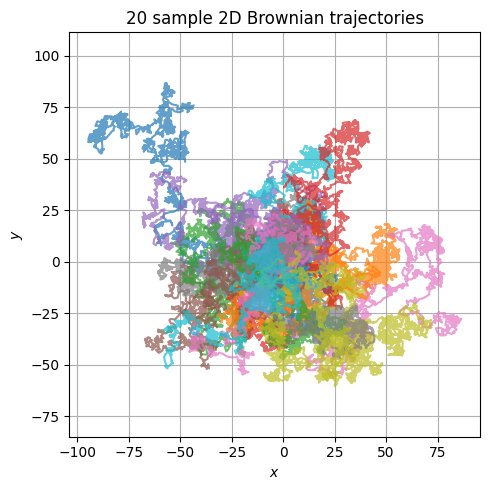

In [66]:
# Plot a few example trajectories in 2D
n_traj = 20   # number of trajectories to show
indices = np.arange(n_traj)

plt.figure(figsize=(5, 5))
for i in indices:
    x = positions_2d[:, i, 0]
    y = positions_2d[:, i, 1]
    plt.plot(x, y, alpha=0.7)

plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(f"{n_traj} sample 2D Brownian trajectories")
plt.axis("equal")
plt.tight_layout()
plt.show()

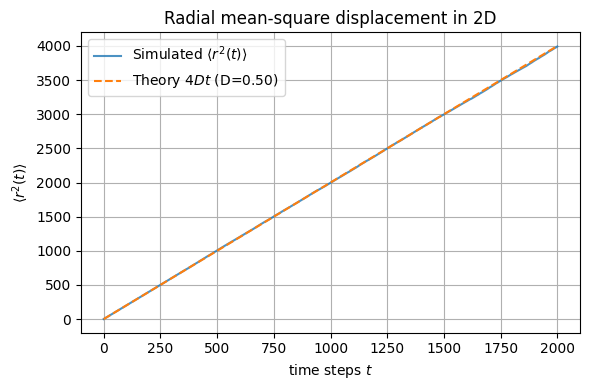

In [67]:
# Time array
t_2d = np.arange(n_steps_2d + 1)

# Mean-square displacement for each coordinate
msd_x = np.mean(positions_2d[:, :, 0]**2, axis=1)
msd_y = np.mean(positions_2d[:, :, 1]**2, axis=1)

# Radial mean-square displacement <r^2> = <x^2 + y^2>
msd_r = msd_x + msd_y

# Theoretical D for discrete steps with Δt = 1
D_2d = step_std_2d**2 / 2.0  # same expression as 1D
msd_r_theory = 4 * D_2d * t_2d

plt.figure(figsize=(6, 4))
plt.plot(t_2d, msd_r, label=r"Simulated $\langle r^2(t) \rangle$", alpha=0.8)
plt.plot(t_2d, msd_r_theory, "--", label=fr"Theory $4Dt$ (D={D_2d:.2f})")
plt.xlabel("time steps $t$")
plt.ylabel(r"$\langle r^2(t) \rangle$")
plt.title("Radial mean-square displacement in 2D")
plt.legend()
plt.tight_layout()
plt.show()

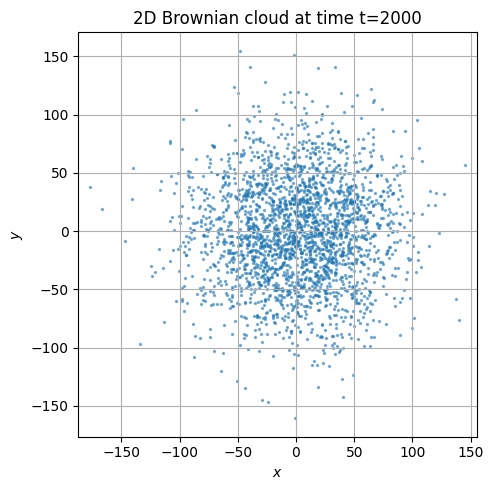

In [68]:
# Positions at final time
x_final_2d = positions_2d[-1, :, 0]
y_final_2d = positions_2d[-1, :, 1]

plt.figure(figsize=(5, 5))
plt.scatter(x_final_2d[::20], y_final_2d[::20], s=2, alpha=0.5, label="Particles")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(f"2D Brownian cloud at time t={n_steps_2d}")
plt.axis("equal")
plt.tight_layout()
plt.show()

### Summary of the 2D extension

Our 2D simulation confirms:

- Each coordinate behaves like an independent 1D Brownian motion.

$$
\langle x^2(t) \rangle = \langle y^2(t) \rangle = 2 D t.
$$

- The radial mean-square displacement grows as

$$
\langle r^2(t) \rangle = 4 D t,
$$

with the same diffusion constant $D$ as in 1D.

- The particle cloud in the $(x,y)$-plane is approximately circular and its density is described by the 2D Gaussian

$$
p(x,y,t) = \frac{1}{4 \pi D t}
\exp\!\left( -\frac{x^2 + y^2}{4 D t} \right).
$$

This is the direct two-dimensional analogue of Einstein's original random-walk
argument and connects naturally to experiments that track colloidal particles
in a microscope field of view.

## Microscopic collision model

So far, we *postulated* that the particle does a random walk. Now we build
a toy **microscopic model** where that randomness emerges from **many collisions**
with smaller particles, similar to the famous Brownian-motion animations.

### Model assumptions

We work in 2D, with:

- One **big disk** (the Brownian particle):
  - Radius $R_{\mathrm{B}}$
  - Mass $M$
  - Position $\mathbf{R}(t)$
  - Velocity $\mathbf{V}(t)$

- $N$ **small disks** (the "molecules"):
  - Radius $R_{\mathrm{s}}$
  - Mass $m$
  - Positions $\mathbf{r}_i(t)$
  - Velocities $\mathbf{v}_i(t)$
  - Initial velocities drawn from a Gaussian as a simple stand-in for a thermal distribution

We place all disks in a square box with **reflecting walls**.

### Equations of motion

Between collisions, each particle just moves freely:

$$
\frac{d\mathbf{R}}{dt} = \mathbf{V}, \quad
\frac{d\mathbf{V}}{dt} = \mathbf{0},
$$

$$
\frac{d\mathbf{r}_i}{dt} = \mathbf{v}_i, \quad
\frac{d\mathbf{v}_i}{dt} = \mathbf{0}
\quad (i = 1,\dots,N).
$$

So we integrate with a simple Euler step:

$$
\mathbf{R}(t+\Delta t) = \mathbf{R}(t) + \mathbf{V}(t)\,\Delta t,
$$

$$
\mathbf{r}_i(t+\Delta t) = \mathbf{r}_i(t) + \mathbf{v}_i(t)\,\Delta t.
$$

### Elastic collisions (big-small)

When a small disk $i$ overlaps with the big one,

$$
\lVert \mathbf{r}_i - \mathbf{R} \rVert < R_{\mathrm{B}} + R_{\mathrm{s}},
$$

we treat it as an **instantaneous elastic collision** between two disks.

Let

- $m_1 = M$, $\mathbf{v}_1 = \mathbf{V}$ for the big particle
- $m_2 = m$, $\mathbf{v}_2 = \mathbf{v}_i$ for the small particle
- $\mathbf{d} = \mathbf{r}_i - \mathbf{R}$
- $d = \|\mathbf{d}\|$
- $\mathbf{n} = \mathbf{d} / d$ be the **unit normal** from big to small

The relative velocity along the line of centers is

$$
v_{\mathrm{n}} = (\mathbf{v}_1 - \mathbf{v}_2)\cdot \mathbf{n}.
$$

For an elastic collision of two disks with no tangential impulse, the post-collision velocities are

$$
\mathbf{v}_1' = \mathbf{v}_1 - \frac{2 m_2}{m_1 + m_2} v_{\mathrm{n}} \mathbf{n},
$$

$$
\mathbf{v}_2' = \mathbf{v}_2 + \frac{2 m_1}{m_1 + m_2} v_{\mathrm{n}} \mathbf{n}.
$$

We only apply this if $v_{\mathrm{n}} > 0$, meaning the disks are approaching.

### Emergent Brownian behaviour

The big particle starts at rest. A sea of small particles with random initial
velocities bounces off it. Each collision gives a small momentum kick. Over
many collisions, the big particle's position $\mathbf{R}(t)$ should behave
approximately like a **2D Brownian motion** with

$$
\langle r^2(t) \rangle = \langle |\mathbf{R}(t) - \mathbf{R}(0)|^2 \rangle
\propto t.
$$

We now simulate this system and:

1. Visualise the big particle wandering among many small ones.
2. Compute $\langle r^2(t) \rangle$ over multiple runs and check its linear growth with $t$.

In [69]:
from numba import njit


def sample_nonoverlapping_small_disks(n_small, box_size, R_small, R_big, big_pos, rng, max_tries=200000):
    """Sample small-disk centers without overlap (small-small and small-big)."""
    positions = np.empty((n_small, 2), dtype=np.float64)
    n_placed = 0
    tries = 0

    min_ss2 = (2.0 * R_small) ** 2
    min_sb2 = (R_small + R_big) ** 2

    while n_placed < n_small and tries < max_tries:
        tries += 1
        x = rng.uniform(R_small, box_size - R_small)
        y = rng.uniform(R_small, box_size - R_small)

        # avoid overlap with big disk
        dx_b = x - big_pos[0]
        dy_b = y - big_pos[1]
        if dx_b * dx_b + dy_b * dy_b < min_sb2:
            continue

        # avoid overlap with already placed small disks
        ok = True
        for j in range(n_placed):
            dx = x - positions[j, 0]
            dy = y - positions[j, 1]
            if dx * dx + dy * dy < min_ss2:
                ok = False
                break

        if ok:
            positions[n_placed, 0] = x
            positions[n_placed, 1] = y
            n_placed += 1

    if n_placed < n_small:
        raise RuntimeError(
            f"Could only place {n_placed}/{n_small} small disks without overlap. "
            "Try fewer particles or smaller radii."
        )

    return positions


@njit
def step_gas_numba(big_pos, big_vel, small_pos, small_vel,
                   box_size, R_big, R_small, M_big, m_small, dt):
    """
    Advance the Brownian gas system by ONE time step (in-place).
    Numba-accelerated version — all loops run in compiled machine code.
    """
    N = small_pos.shape[0]

    # --- free flight ---
    for i in range(N):
        small_pos[i, 0] += small_vel[i, 0] * dt
        small_pos[i, 1] += small_vel[i, 1] * dt
    big_pos[0] += big_vel[0] * dt
    big_pos[1] += big_vel[1] * dt

    # --- reflect small particles at walls ---
    for i in range(N):
        for dim in range(2):
            if small_pos[i, dim] < R_small:
                small_pos[i, dim] = 2.0 * R_small - small_pos[i, dim]
                small_vel[i, dim] *= -1.0
            elif small_pos[i, dim] > box_size - R_small:
                small_pos[i, dim] = 2.0 * (box_size - R_small) - small_pos[i, dim]
                small_vel[i, dim] *= -1.0

    # --- reflect big particle at walls ---
    for dim in range(2):
        if big_pos[dim] < R_big:
            big_pos[dim] = 2.0 * R_big - big_pos[dim]
            big_vel[dim] *= -1.0
        elif big_pos[dim] > box_size - R_big:
            big_pos[dim] = 2.0 * (box_size - R_big) - big_pos[dim]
            big_vel[dim] *= -1.0

    # --- collisions big-small ---
    eps = 1e-12
    R_tot = R_big + R_small + eps
    R_tot2 = R_tot * R_tot

    for i in range(N):
        dx = small_pos[i, 0] - big_pos[0]
        dy = small_pos[i, 1] - big_pos[1]
        dist2 = dx * dx + dy * dy
        if dist2 < R_tot2:
            dist = np.sqrt(dist2)
            if dist == 0.0:
                continue

            n_x = dx / dist
            n_y = dy / dist

            rel_x = big_vel[0] - small_vel[i, 0]
            rel_y = big_vel[1] - small_vel[i, 1]
            vn = rel_x * n_x + rel_y * n_y

            # approaching means (v_big - v_small)·n > 0
            if vn > 0.0:
                m_sum = M_big + m_small
                c1 = 2.0 * m_small / m_sum
                c2 = 2.0 * M_big / m_sum

                big_vel[0] -= c1 * vn * n_x
                big_vel[1] -= c1 * vn * n_y
                small_vel[i, 0] += c2 * vn * n_x
                small_vel[i, 1] += c2 * vn * n_y

                overlap = R_tot - dist
                if overlap > 0.0:
                    sb = overlap * m_small / m_sum
                    ss = overlap * M_big / m_sum
                    big_pos[0] -= n_x * sb
                    big_pos[1] -= n_y * sb
                    small_pos[i, 0] += n_x * ss
                    small_pos[i, 1] += n_y * ss

    # --- small-small collisions (O(N^2)) ---
    R_ss = 2.0 * R_small + eps
    R_ss2 = R_ss * R_ss

    for i in range(N):
        for j in range(i + 1, N):
            dx = small_pos[j, 0] - small_pos[i, 0]
            dy = small_pos[j, 1] - small_pos[i, 1]
            dist2 = dx * dx + dy * dy
            if dist2 < R_ss2:
                dist = np.sqrt(dist2)
                if dist == 0.0:
                    continue

                n_x = dx / dist
                n_y = dy / dist

                rel_x = small_vel[i, 0] - small_vel[j, 0]
                rel_y = small_vel[i, 1] - small_vel[j, 1]
                un = rel_x * n_x + rel_y * n_y

                # approaching means (v_i - v_j)·n > 0
                if un > 0.0:
                    # equal masses: exchange normal component
                    small_vel[i, 0] -= un * n_x
                    small_vel[i, 1] -= un * n_y
                    small_vel[j, 0] += un * n_x
                    small_vel[j, 1] += un * n_y

                    overlap = R_ss - dist
                    if overlap > 0.0:
                        shift = 0.5 * overlap
                        small_pos[i, 0] -= shift * n_x
                        small_pos[i, 1] -= shift * n_y
                        small_pos[j, 0] += shift * n_x
                        small_pos[j, 1] += shift * n_y


# Warm up the JIT (first call triggers compilation)
_dummy = np.zeros((2,), dtype=np.float64)
_dummys = np.zeros((2, 2), dtype=np.float64)
step_gas_numba(_dummy.copy(), _dummy.copy(), _dummys.copy(), _dummys.copy(),
               1.0, 0.1, 0.01, 10.0, 1.0, 0.001)
print("Numba JIT compiled successfully.")

Numba JIT compiled successfully.


In [70]:
def simulate_brownian_gas(
    n_small=200,
    box_size=1.0,
    R_big=0.08,
    R_small=0.01,
    M_big=100.0,
    m_small=1.0,
    v_small_rms=1.0,
    dt=0.002,
    n_steps=20000,
    seed=0,
):
    rng = np.random.default_rng(seed)

    big_pos = np.array([box_size / 2, box_size / 2], float)
    big_vel = np.array([0.0, 0.0], float)

    small_pos = sample_nonoverlapping_small_disks(
        n_small=n_small,
        box_size=box_size,
        R_small=R_small,
        R_big=R_big,
        big_pos=big_pos,
        rng=rng,
    )
    std = v_small_rms / np.sqrt(2)
    small_vel = rng.normal(0.0, std, size=(n_small, 2))

    big_traj = np.zeros((n_steps + 1, 2))
    big_traj[0] = big_pos

    for t in range(1, n_steps + 1):
        step_gas_numba(big_pos, big_vel, small_pos, small_vel,
                       box_size, R_big, R_small, M_big, m_small, dt)
        big_traj[t] = big_pos

    return big_traj, small_pos, small_vel

In [71]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# --- initial state ---
rng = np.random.default_rng(0)

box_size = 1.0
R_big = 0.08
R_small = 0.01
M_big = 50.0
m_small = 1.0
n_small = 200
v_small_rms = 1.5
dt = 0.001
substeps_per_frame = 50

big_pos = np.array([box_size / 2, box_size / 2], float)
big_vel = np.array([0.0, 0.0], float)

small_pos = sample_nonoverlapping_small_disks(
    n_small=n_small,
    box_size=box_size,
    R_small=R_small,
    R_big=R_big,
    big_pos=big_pos,
    rng=rng,
)
std = v_small_rms / np.sqrt(2)
small_vel = rng.normal(0.0, std, size=(n_small, 2))

# store trajectory history of big particle
big_traj_x = [big_pos[0]]
big_traj_y = [big_pos[1]]

tail_length = None

# --- matplotlib setup ---
fig, ax = plt.subplots(figsize=(5, 5))

scat_small = ax.scatter(
    small_pos[:, 0], small_pos[:, 1],
    s=10, alpha=0.6
)
scat_big = ax.scatter(
    [big_pos[0]], [big_pos[1]],
    s=400, edgecolor="k", facecolor="none"
)
traj_line, = ax.plot(big_traj_x, big_traj_y, lw=1.0)

ax.set_xlim(0, box_size)
ax.set_ylim(0, box_size)
ax.set_aspect("equal", "box")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Brownian motion: big particle in sea of small particles")

def init():
    scat_small.set_offsets(small_pos)
    scat_big.set_offsets(big_pos[None, :])
    traj_line.set_data(big_traj_x, big_traj_y)
    return scat_small, scat_big, traj_line

def update(frame):
    global big_pos, big_vel, small_pos, small_vel, big_traj_x, big_traj_y

    if frame < 0:
        raise ValueError("Frame index must be non-negative")

    # multiple substeps per frame for smooth motion
    for _ in range(substeps_per_frame):
        step_gas_numba(
            big_pos, big_vel, small_pos, small_vel,
            box_size, R_big, R_small, M_big, m_small, dt
        )

    big_traj_x.append(big_pos[0])
    big_traj_y.append(big_pos[1])

    if tail_length is not None:
        x_tail = big_traj_x[-tail_length:]
        y_tail = big_traj_y[-tail_length:]
    else:
        x_tail = big_traj_x
        y_tail = big_traj_y

    scat_small.set_offsets(small_pos)
    scat_big.set_offsets(big_pos[None, :])
    traj_line.set_data(x_tail, y_tail)
    return scat_small, scat_big, traj_line

n_frames = 200

ani = FuncAnimation(
    fig, update, frames=n_frames,
    init_func=init, blit=True, interval=30
)

writer = PillowWriter(fps=30)
ani.save("brownian.gif", writer=writer)
plt.close(fig)
print("Saved brownian.gif")

Saved brownian.gif


{
  "cell_type": "markdown",
  "metadata": {
    "language": "markdown"
  },
  "source": [
    "### Brownian-motion animation",
    "",
    "The animation below is stored as a repository asset, so it will render on GitHub before the code used to generate it.",
    "",
    "![Brownian motion animation](brownian.gif)"
  ]
}

## Diffusion, flux, and Fick's law

So far we followed a single particle through the probability density $p(x,t)$. For a
large number of particles, we introduce the **concentration** $n(x,t)$,
meaning the number of particles per unit volume.

Empirically, diffusion was known to follow **Fick's first law**:

$$
\boxed{
J(x,t) = -D \frac{\partial n(x,t)}{\partial x}
}
$$

where:

- $J(x,t)$ is the **particle flux**, the number of particles crossing unit area per unit time
- $D$ is the same diffusion constant

Conservation of particle number is expressed by the **continuity equation**:

$$
\frac{\partial n}{\partial t} + \frac{\partial J}{\partial x} = 0.
$$

Substituting Fick's law into the continuity equation gives

$$
\frac{\partial n}{\partial t}
= D \frac{\partial^2 n}{\partial x^2},
$$

which is again the **diffusion equation**.

Thus, the same $D$ that controls the microscopic random walk also controls the
macroscopic spreading of a cloud of particles.

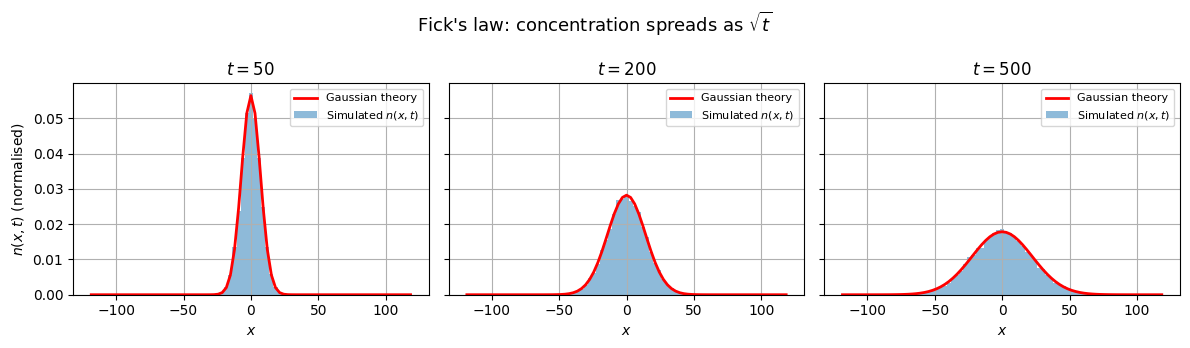

In [72]:
# --- Demonstrate Fick's law with a simulation ---
# Start particles at x=0 and let them diffuse.
# Then compare the concentration profile n(x,t) to the Gaussian theory.

rng_fick = np.random.default_rng(42)
n_part = 20_000
D_fick = 0.5  # step_std=1, dt=1

times = [50, 200, 500]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)

for ax, t_snap in zip(axes, times):
    rng_t = np.random.default_rng(42)
    x_t = np.zeros(n_part)
    for _ in range(t_snap):
        x_t += rng_t.normal(0.0, 1.0, size=n_part)

    # histogram → concentration
    bins = np.linspace(-120, 120, 80)
    counts, edges = np.histogram(x_t, bins=bins, density=True)
    centres = 0.5 * (edges[:-1] + edges[1:])

    # theoretical Gaussian
    sigma = np.sqrt(2 * D_fick * t_snap)
    theory = (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-centres**2 / (2 * sigma**2))

    ax.bar(centres, counts, width=edges[1] - edges[0], alpha=0.5, label="Simulated $n(x,t)$")
    ax.plot(centres, theory, "r-", lw=2, label="Gaussian theory")
    ax.set_xlabel("$x$")
    ax.set_title(f"$t = {t_snap}$")
    if ax is axes[0]:
        ax.set_ylabel("$n(x,t)$ (normalised)")
    ax.legend(fontsize=8)

fig.suptitle(r"Fick's law: concentration spreads as $\sqrt{t}$", fontsize=13)
plt.tight_layout()
plt.show()

## Drift + diffusion and the Einstein relation

Einstein's next step is to consider suspended particles under an **external
force** $F(x)$, for example gravity or an electric field.

The total flux $J$ has two parts.

First, the **diffusive flux** from random motion:

$$
J_{\mathrm{diff}} = -D \frac{\partial n}{\partial x}.
$$

Second, the **drift flux** from a systematic force $F$. Define the **mobility**
$\mu$ by

$$
v_{\mathrm{drift}} = \mu F,
$$

so the drift contribution is

$$
J_{\mathrm{drift}} = n v_{\mathrm{drift}} = \mu F n.
$$

The total flux is therefore

$$
\boxed{
J = -D \frac{\partial n}{\partial x} + \mu F n.
}
$$

At **thermal equilibrium**, there is no net flux:

$$
J = 0 \quad \Rightarrow \quad
-D \frac{d n}{d x} + \mu F n = 0.
$$

Rearranging gives

$$
\frac{1}{n} \frac{d n}{d x} = \frac{\mu}{D} F.
$$

On the other hand, equilibrium in a potential $U(x)$ with
$F(x) = -\dfrac{dU}{dx}$ is described by the **Boltzmann distribution**:

$$
n(x) \propto e^{-U(x)/(k_B T)}.
$$

Therefore,

$$
\frac{1}{n} \frac{d n}{d x}
= -\frac{1}{k_B T} \frac{dU}{dx}
= \frac{F}{k_B T}.
$$

Comparing the two expressions gives

$$
\frac{\mu}{D} F = \frac{1}{k_B T} F
\quad \Rightarrow \quad
\boxed{ D = \mu k_B T }.
$$

This is the **Einstein relation**: the same random fluctuations (diffusion)
and systematic response (mobility) are linked by the temperature $T$.
It is an early example of a **fluctuation-dissipation relation**.

For the numerical example below, we place the particles in a **finite interval with reflecting walls**. That confinement matters: a constant force can produce a stationary Boltzmann profile in a box, but not on a periodic domain.

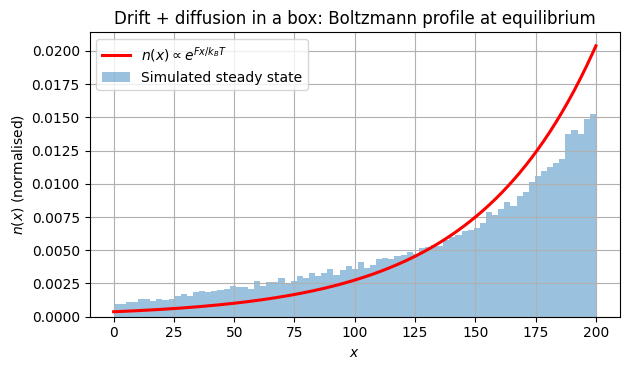

In [73]:
# --- Drift-diffusion simulation demonstrating the Einstein relation ---
# Particles diffuse and drift under a constant force F in a finite box.
# With reflecting walls, the stationary distribution satisfies J = 0 and
# should follow n(x) ∝ exp(F x / k_B T).

rng_drift = np.random.default_rng(7)

n_part_drift = 50_000
n_steps_drift = 8_000
D_drift = 0.5
dt_drift = 1.0
kBT = 1.0                      # k_B T in simulation units
mu_drift = D_drift / kBT       # Einstein relation: D = μ k_B T
F_ext = 0.02                   # constant external force

# finite box [0, L] with reflecting walls
L_box = 200.0
x_drift = rng_drift.uniform(0, L_box, size=n_part_drift)
noise_std = np.sqrt(2 * D_drift * dt_drift)
drift_step = mu_drift * F_ext * dt_drift

for _ in range(n_steps_drift):
    x_drift += rng_drift.normal(0.0, noise_std, size=n_part_drift) + drift_step

    # Reflect repeatedly if a large fluctuation crosses a wall by more than one box length.
    while True:
        left = x_drift < 0.0
        if np.any(left):
            x_drift[left] = -x_drift[left]

        right = x_drift > L_box
        if np.any(right):
            x_drift[right] = 2.0 * L_box - x_drift[right]

        if not (np.any(x_drift < 0.0) or np.any(x_drift > L_box)):
            break

# Expected equilibrium in a box: n(x) ∝ exp(F x / k_B T)
bins_d = np.linspace(0, L_box, 80)
counts_d, edges_d = np.histogram(x_drift, bins=bins_d, density=True)
centres_d = 0.5 * (edges_d[:-1] + edges_d[1:])

x_th = np.linspace(0, L_box, 400)
boltz = np.exp(F_ext * x_th / kBT)
boltz /= np.trapezoid(boltz, x_th)

plt.figure(figsize=(6.4, 3.8))
plt.bar(centres_d, counts_d, width=edges_d[1] - edges_d[0],
        alpha=0.45, label="Simulated steady state")
plt.plot(x_th, boltz, "r-", lw=2.2, label=r"$n(x) \propto e^{F x / k_B T}$")
plt.xlabel("$x$")
plt.ylabel("$n(x)$ (normalised)")
plt.title("Drift + diffusion in a box: Boltzmann profile at equilibrium")
plt.legend()
plt.tight_layout()
plt.show()

## Hydrodynamics + Einstein relation = Stokes-Einstein

To make contact with measurable quantities, Einstein now needs $\mu$, the
**mobility** of a small particle in a viscous fluid.

For a spherical particle of radius $a$ moving at a small steady velocity $v$
through a fluid of viscosity $\eta$, **Stokes' law** for viscous drag gives

$$
F_{\mathrm{drag}} = 6 \pi \eta a\, v.
$$

If a constant external force $F$ acts on the particle, then in steady motion
the drag balances the applied force:

$$
F = 6 \pi \eta a\, v_{\mathrm{drift}}.
$$

Thus

$$
v_{\mathrm{drift}} = \frac{F}{6 \pi \eta a},
$$

and the mobility is

$$
\mu = \frac{v_{\mathrm{drift}}}{F}
= \frac{1}{6 \pi \eta a}.
$$

Insert this into the Einstein relation $D = \mu k_B T$:

$$
\boxed{
D = \frac{k_B T}{6 \pi \eta a}.
}
$$

In terms of the gas constant $R$ and **Avogadro's number** $N$, with
$k_B = R/N$, this becomes

$$
\boxed{
D = \frac{R T}{6 \pi N \eta a}.
}
$$

This is the **Stokes-Einstein formula**. Measuring $D$, $\eta$, $T$, and $a$
allows one to determine $N$. Jean Perrin later did exactly this in carefully
controlled experiments, providing strong evidence for the atomic theory of
matter.

In [74]:
# --- Compute D from the Stokes–Einstein formula for realistic parameters ---

k_B = 1.380649e-23       # Boltzmann constant [J/K]
T   = 300.0               # Temperature [K]
eta = 1.0e-3              # Water viscosity at ~25°C [Pa·s]
a   = 1.0e-6              # Particle radius [m]  (1 μm)
N_A = 6.022e23            # Avogadro's number [mol⁻¹]
R_gas = k_B * N_A         # Gas constant [J/(mol·K)]

D_SE = k_B * T / (6 * np.pi * eta * a)

print("Stokes–Einstein diffusion constant")
print(f"  k_B   = {k_B:.4e} J/K")
print(f"  T     = {T:.0f} K")
print(f"  η     = {eta:.1e} Pa·s")
print(f"  a     = {a:.1e} m")
print(f"  D     = {D_SE:.4e} m²/s")
print()

# Predict mean-square displacement after 1 second
t_obs = 1.0  # seconds
msd_1s = 2 * D_SE * t_obs
x_rms = np.sqrt(msd_1s)
print(f"After t = {t_obs} s:")
print(f"  <x²>  = 2Dt = {msd_1s:.4e} m²")
print(f"  x_rms = √(2Dt) = {x_rms*1e6:.2f} μm")
print()

# Infer Avogadro's number from D (as Einstein proposed)
N_inferred = R_gas * T / (6 * np.pi * eta * a * D_SE)
print(f"Avogadro's number inferred from D:")
print(f"  N = RT / (6πηaD) = {N_inferred:.4e}")

Stokes–Einstein diffusion constant
  k_B   = 1.3806e-23 J/K
  T     = 300 K
  η     = 1.0e-03 Pa·s
  a     = 1.0e-06 m
  D     = 2.1974e-13 m²/s

After t = 1.0 s:
  <x²>  = 2Dt = 4.3947e-13 m²
  x_rms = √(2Dt) = 0.66 μm

Avogadro's number inferred from D:
  N = RT / (6πηaD) = 6.0220e+23


## Real units

In the simulation above we used **dimensionless units**:

- Time step: $\Delta t = 1$
- Step standard deviation: $\sigma = \mathrm{step\_std} = 1$
- So $D_{\mathrm{sim}} = \sigma^2 / (2 \Delta t) = 0.5$

In real physical units, we can choose parameters typical of Brownian motion
for a micron-sized particle in water:

- Temperature $T \approx 300\,\mathrm{K}$
- Water viscosity $\eta \approx 10^{-3}\,\mathrm{Pa\cdot s}$
- Particle radius $a \approx 1\,\mu\mathrm{m} = 10^{-6}\,\mathrm{m}$
- Boltzmann constant $k_B \approx 1.38 \times 10^{-23}\,\mathrm{J/K}$

From the Stokes-Einstein formula,

$$
D_{\mathrm{phys}} = \frac{k_B T}{6 \pi \eta a}.
$$

We can compute this and then choose $\Delta t$ and $\sigma$ so that our
discrete random walk has the same $D$.

This $D_{\mathrm{phys}}$ is in units of $\mathrm{m}^2/\mathrm{s}$. Suppose we choose a
simulation time step $\Delta t_{\mathrm{phys}} = 1\,\mathrm{ms} = 10^{-3}\,\mathrm{s}$.
For a 1D random walk with Gaussian steps, we want

$$
D_{\mathrm{phys}} = \frac{\sigma_{\mathrm{phys}}^2}{2 \Delta t_{\mathrm{phys}}}
\quad \Rightarrow \quad
\sigma_{\mathrm{phys}} = \sqrt{2 D_{\mathrm{phys}} \Delta t_{\mathrm{phys}} }.
$$

We can therefore compute the typical step size.

The value `sigma_phys` tells us the **typical displacement per millisecond**
for such a particle. It is small, but over many time steps the mean-square
displacement grows linearly:

$$
\langle x^2(t) \rangle = 2 D_{\mathrm{phys}} t.
$$

This is exactly the relation Einstein used, in the form

$$
\boxed{
\langle x^2(t) \rangle = \frac{R T}{3 \pi N \eta a} t
}
$$

for 1D motion. By measuring the slope of $\langle x^2(t) \rangle$ versus $t$,
one can infer the value of $N$.

D_phys          = 2.1974e-13 m²/s
Δt_phys         = 1.0 ms
σ_phys per step = 2.0964e-08 m = 21.0 nm



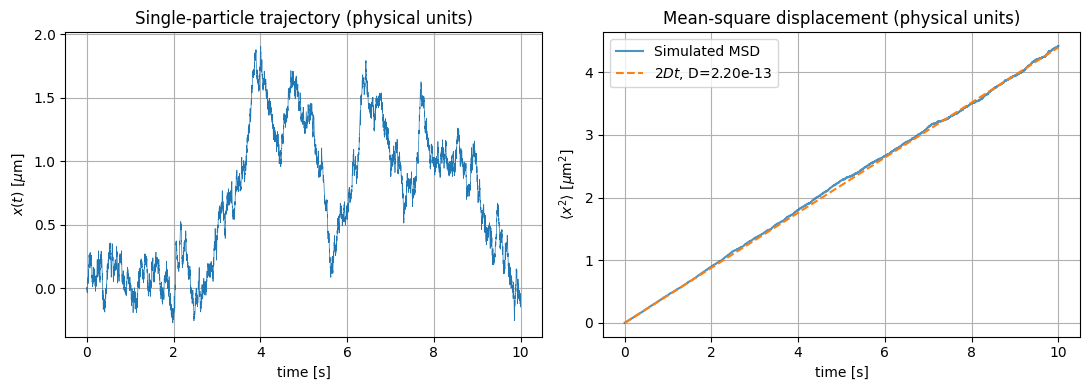


Measured slope / 2 → D_meas = 2.1900e-13 m²/s
Inferred Avogadro's number  = 6.0422e+23  (true: 6.022e+23)


In [75]:
# --- Map our discrete random walk to real physical units ---

# Physical parameters (same as above)
D_phys = k_B * T / (6 * np.pi * eta * a)  # m²/s

# Choose a simulation time step
dt_phys = 1.0e-3  # 1 millisecond

# Required step std to match D_phys
sigma_phys = np.sqrt(2 * D_phys * dt_phys)

print(f"D_phys          = {D_phys:.4e} m²/s")
print(f"Δt_phys         = {dt_phys*1e3:.1f} ms")
print(f"σ_phys per step = {sigma_phys:.4e} m = {sigma_phys*1e9:.1f} nm")
print()

# Simulate 10 s of Brownian motion in physical units
n_steps_phys = int(10.0 / dt_phys)  # 10 seconds
rng_phys = np.random.default_rng(99)

x_phys = np.cumsum(rng_phys.normal(0, sigma_phys, size=n_steps_phys))
t_phys = np.arange(1, n_steps_phys + 1) * dt_phys

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# trajectory
ax1.plot(t_phys, x_phys * 1e6, lw=0.5)
ax1.set_xlabel("time [s]")
ax1.set_ylabel(r"$x(t)$ [$\mu$m]")
ax1.set_title("Single-particle trajectory (physical units)")

# MSD from ensemble
n_ens = 5000
all_x = np.cumsum(rng_phys.normal(0, sigma_phys, size=(n_steps_phys, n_ens)), axis=0)
msd_phys = np.mean(all_x**2, axis=1)
msd_theory_phys = 2 * D_phys * t_phys

ax2.plot(t_phys, msd_phys * 1e12, alpha=0.8, label="Simulated MSD")
ax2.plot(t_phys, msd_theory_phys * 1e12, "--", label=f"$2Dt$, D={D_phys:.2e}")
ax2.set_xlabel("time [s]")
ax2.set_ylabel(r"$\langle x^2 \rangle$ [$\mu$m$^2$]")
ax2.set_title("Mean-square displacement (physical units)")
ax2.legend()

plt.tight_layout()
plt.show()

# Infer N from the slope of MSD vs t
slope = np.polyfit(t_phys, msd_phys, 1)[0]
D_meas = slope / 2.0
N_meas = R_gas * T / (6 * np.pi * eta * a * D_meas)
print(f"\nMeasured slope / 2 → D_meas = {D_meas:.4e} m²/s")
print(f"Inferred Avogadro's number  = {N_meas:.4e}  (true: 6.022e+23)")

## References

- A. Einstein, "Über die von der molekularkinetischen Theorie der Wärme
  geforderte Bewegung von in ruhenden Flüssigkeiten suspendierten Teilchen",
  *Annalen der Physik* **322**, 549–560 (1905).

- N. G. van Kampen, *Stochastic Processes in Physics and Chemistry*,
  North-Holland (1992).

- C. W. Gardiner, *Handbook of Stochastic Methods*, Springer (1985).